# Store 1 to Store 2 Item Matching using TF-IDF
Match clothing items from store_1 to store_2 based on item descriptions using TF-IDF vectorization.

In [36]:
import pandas as pd
import numpy as np
from glob import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import spacy

In [37]:
# Load data efficiently
data_dir = "datasets/"

# Load store_1 files in one operation
store_1_files = sorted(glob(f"{data_dir}store_1*.csv"))
df_1 = pd.concat([pd.read_csv(f) for f in store_1_files], ignore_index=True)

# Load store_2
df_2 = pd.read_csv(f"{data_dir}store_2.csv", low_memory=False)

print(f"Store 1: {df_1.shape}")
print(f"Store 2: {df_2.shape}")

Store 1: (132561, 31)
Store 2: (75634, 27)


In [38]:
# Load spaCy model for text preprocessing
nlp_model = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess_batch(series, batch_size=1000):
    """Extract lemmatized tokens from text, removing stopwords and punctuation."""
    results = []
    docs = nlp_model.pipe(series.fillna(""), batch_size=batch_size)
    
    for doc in docs:
        lemmas = [w.lemma_.lower() for w in doc 
                 if not (w.is_stop or w.is_space or w.is_punct)]
        results.append(" ".join(lemmas))
    
    return results

# Preprocess item descriptions
df_1["processed_text"] = preprocess_batch(df_1["Item"])
df_2["processed_text"] = preprocess_batch(df_2["Item"])

In [39]:
# TF-IDF Vectorization - fit on combined vocabulary
tfidf_vectorizer = TfidfVectorizer()

# Fit on combined corpus to ensure consistent vocabulary
all_texts = pd.concat([df_1["processed_text"], df_2["processed_text"]])
tfidf_vectorizer.fit(all_texts)

# Transform to sparse matrices
X_store1 = tfidf_vectorizer.transform(df_1["processed_text"])
X_store2 = tfidf_vectorizer.transform(df_2["processed_text"])

print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Store 1 matrix shape: {X_store1.shape}")
print(f"Store 2 matrix shape: {X_store2.shape}")

Vocabulary size: 12171
Store 1 matrix shape: (132561, 12171)
Store 2 matrix shape: (75634, 12171)


In [40]:
# Compute similarities in batches to avoid memory issues
batch_size = 5000
matches = []

for start_idx in range(0, len(df_1), batch_size):
    end_idx = min(start_idx + batch_size, len(df_1))
    
    # Compute similarity for this batch
    batch_similarities = cosine_similarity(X_store1[start_idx:end_idx], X_store2)
    
    # Find best match for each item
    best_match_indices = batch_similarities.argmax(axis=1)
    best_match_scores = batch_similarities[range(len(best_match_indices)), best_match_indices]
    
    # Store results
    for i, (match_idx, score) in enumerate(zip(best_match_indices, best_match_scores)):
        matches.append({
            "store_1_index": start_idx + i,
            "store_2_index": match_idx,
            "similarity_score": score
        })
    
    print(f"Processed {end_idx}/{len(df_1)} items")

# Create matches dataframe
matches_df = pd.DataFrame(matches)
matches_df["store_1_item"] = df_1["Item"].values
matches_df["store_2_item"] = df_2["Item"].iloc[matches_df["store_2_index"]].values

Processed 5000/132561 items
Processed 10000/132561 items
Processed 15000/132561 items
Processed 20000/132561 items
Processed 25000/132561 items
Processed 30000/132561 items
Processed 35000/132561 items
Processed 40000/132561 items
Processed 45000/132561 items
Processed 50000/132561 items
Processed 55000/132561 items
Processed 60000/132561 items
Processed 65000/132561 items
Processed 70000/132561 items
Processed 75000/132561 items
Processed 80000/132561 items
Processed 85000/132561 items
Processed 90000/132561 items
Processed 95000/132561 items
Processed 100000/132561 items
Processed 105000/132561 items
Processed 110000/132561 items
Processed 115000/132561 items
Processed 120000/132561 items
Processed 125000/132561 items
Processed 130000/132561 items
Processed 132561/132561 items


In [41]:
# Show match quality statistics
print("Match Quality Statistics:")
print(f"Mean similarity: {matches_df['similarity_score'].mean():.3f}")
print(f"Median similarity: {matches_df['similarity_score'].median():.3f}")
print(f"Min similarity: {matches_df['similarity_score'].min():.3f}")
print(f"Max similarity: {matches_df['similarity_score'].max():.3f}")
print(f"\nScore distribution:")
print(matches_df['similarity_score'].describe())

Match Quality Statistics:
Mean similarity: 0.419
Median similarity: 0.384
Min similarity: 0.000
Max similarity: 1.000

Score distribution:
count    132561.000000
mean          0.418558
std           0.226931
min           0.000000
25%           0.248239
50%           0.384287
75%           0.564573
max           1.000000
Name: similarity_score, dtype: float64


In [42]:
# Show examples of matches at different quality levels
print("\n=== TOP 10 BEST MATCHES ===")
top_matches = matches_df.nlargest(10, 'similarity_score')
for _, row in top_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")

print("\n\n=== 10 MEDIAN MATCHES ===")
median_score = matches_df['similarity_score'].median()
median_matches = matches_df.iloc[(matches_df['similarity_score'] - median_score).abs().argsort()[:10]]
for _, row in median_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")

print("\n\n=== 10 WORST MATCHES ===")
worst_matches = matches_df.nsmallest(10, 'similarity_score')
for _, row in worst_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")


=== TOP 10 BEST MATCHES ===

Score: 1.000
  Store 1: Ciele GoCap - Century - Tropograph
  Store 2: Ciele GOCap Century (Tropograph)

Score: 1.000
  Store 1: Outdoor Sports Wipes Peppermint XL
  Store 2: Outdoor Sports Wipes (Peppermint) XL

Score: 1.000
  Store 1: W Smartwool Merino Sport 150 Tank F78 MD
  Store 2: Smartwool Merino Sport 150 Tank (F78) MD

Score: 1.000
  Store 1: Ciele GOCap - C Plus Box - Wyndham
  Store 2: Ciele GoCap C Plus Box (Wyndham)

Score: 1.000
  Store 1: U Salomon Active Skin 8 Set  Surf the Web SM
  Store 2: Salomon Active Skin 8 Set (Surf The Web) SM

Score: 1.000
  Store 1: U Salomon Active Skin 8 Set  Surf the Web MD
  Store 2: Salomon Active Skin 8 Set (Surf The Web) MD

Score: 1.000
  Store 1: Hoka Restore TC BBLC M5/W6
  Store 2: Hoka Restore TC BBLC M5/W6

Score: 1.000
  Store 1: Hoka Restore TC BBLC M11/W12
  Store 2: Hoka Restore TC BBLC  M11/W12

Score: 1.000
  Store 1: Hydro Flask 32 OZ WIDE FLEX CAP Dew
  Store 2: Hydro Flask Wide Flex Cap (Dew

In [43]:
# Show 20 random examples
print("\n\n=== 20 RANDOM MATCH EXAMPLES ===")
random_matches = matches_df.sample(20, random_state=42)
for _, row in random_matches.iterrows():
    print(f"\nScore: {row['similarity_score']:.3f}")
    print(f"  Store 1: {row['store_1_item']}")
    print(f"  Store 2: {row['store_2_item']}")



=== 20 RANDOM MATCH EXAMPLES ===

Score: 0.265
  Store 1: W New Balance W880HP8 2A 7
  Store 2: New Balance Women's 840 V4 (GO) 5 2A

Score: 0.340
  Store 1: W New Balance WW813GY1 2A 10
  Store 2: W Brooks Ghost 12 2A 10

Score: 0.291
  Store 1: M New Balance M880A10 2E 11.5
  Store 2: New Balance Men's More Trail v3 (CA) 11 2E

Score: 0.235
  Store 1: W New Balance 880v13 W880B13 2E 10
  Store 2: W Brooks Dyad 10 2E 10.5

Score: 0.098
  Store 1: K New Balance YP680BB6 W 6.5
  Store 2: New Balance Men's Summit K.O.M (GO) 8 D

Score: 0.366
  Store 1: Asics Thermal Run Glove - S-44197 0090 S/M
  Store 2: Smartwool Merino Thermal Glove (Charcoal) M

Score: 0.384
  Store 1: M New Balance MW577WT 2E 14
  Store 2: Brooks Cascadia 14 2E 14

Score: 0.361
  Store 1: M New Balance M1080K13 2E 12
  Store 2: Brooks Ghost 12 2E 12

Score: 0.616
  Store 1: Run Cold Weather TC Crew Socks Alpine Blue MD
  Store 2: Smartwool Run TC Cold Crew (BLK) MD

Score: 0.261
  Store 1: Yak Trax Pro - P-5690 BK

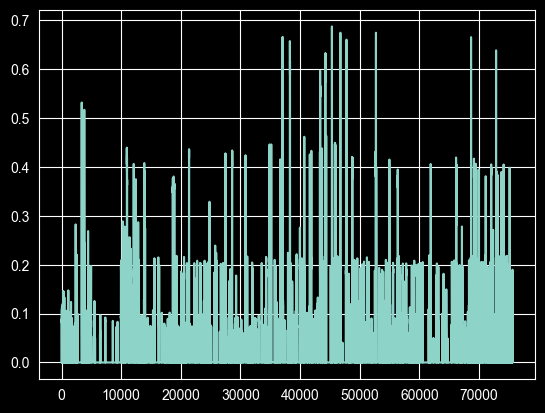

In [46]:
import matplotlib.pyplot as plt

plt.plot(batch_similarities[0])
plt.show()